In [3]:
import numpy as np
from numpy.fft import fft, ifft
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron
from scipy.sparse.linalg import expm_multiply
from os.path import join, exists
from os import mkdir
from utils import *

In [4]:
IMG_DIR = "figures"
if not exists(IMG_DIR):
    mkdir(IMG_DIR)

## Scalar nonlinear hyperbolic PDE 

We target scalar hyperbolic PDE of the form
$$
    \partial_t u + F(u) \cdot \nabla_x u + Q(x,u) = 0.
$$

The level set equation yields the PDE 
$$
    \partial_t \psi + F(p) \cdot \nabla_x \psi - Q(x,p) \partial_p \psi = 0.
$$

As an example, we will try to solve
$$
    \partial_t u + u \cdot \nabla_x u + x = 0,
$$
i.e. the case when $F(u)=u$ and $Q(x,p)=x$.

For the boundary condition, we will enforce $u(0,0)=0$. The solution is determined by the left boundary condition. 

We first solve the PDE using the Lax-Wendroff method.

In [157]:
M = 1
N = 256
N_p = N
h = 1/(N-1)
m = 10
omega = (m * h) ** (1/2)
L, R = 0, 1

In [158]:
def f(u):
    return u * u / 2

def A(u):
    return u

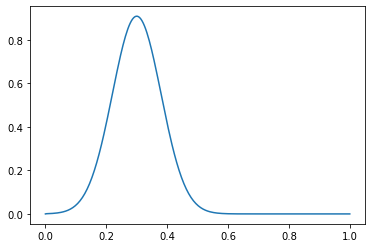

dt/dx = 0.99609375


In [159]:
mu = 0.3
sigma = 0.08
x = np.linspace(L, R, N)
u = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / 1.1
u[0] = 0
# u[-1] = 0
plt.plot(x, u)
plt.show()

N_t = 512
T = 2
dt = T / N_t
dx = (R-L) / (N-1)
print(f"dt/dx = {dt / dx}")
sol = [np.copy(u)]

for i in range(N_t):
    u_next = np.zeros_like(u)
    for j in range(N):
        if j < 0:
            left_val = 0
        else:
            left_val = u[j-1]
        if j >= N-1:
            right_val = 0
        else:
            right_val = u[j+1]
        
        # Advection equation
        u_next[j] = u[j] - 0.5 * (dt/dx) * (right_val - left_val) + 0.5 * ((dt/dx) ** 2) * (left_val - 2 * u[j] + right_val)
        # Burger's equation
        # u_next[j] = u[j] - 0.5 * (dt/dx) * (f(right_val) - f(left_val)) + 0.5 * ((dt/dx) ** 2) * (A((left_val + u[j])/2) * (f(left_val) - f(u[j]) - A((u[j] + right_val)/2) * (f(u[j]) - f(right_val))))


    # u_next[0] = 0
    # u_next[-1] = 0
    sol.append(np.copy(u_next))
    u = u_next
    

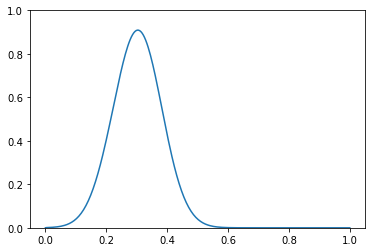

In [148]:
plt.plot(x, sol[1])
plt.ylim([0, 1])
plt.show()

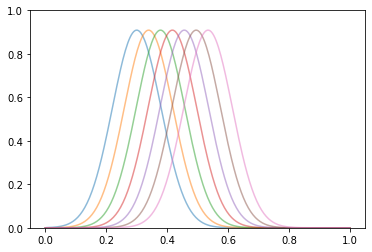

In [156]:
for i in np.arange(0, 65, 10):
    plt.plot(x, sol[i], alpha=0.5)
    plt.ylim([0, 1])
plt.show()

### Burgers' equation

In [11]:
x, p = np.meshgrid(np.linspace(L, R, N), np.linspace(L, R, N_p), indexing='ij')

In [12]:
mu = [0.3, 0.7]
sigma = [0.08, 0.05]
# u_0 = np.zeros_like(x)
# u_0 = u_0[np.newaxis,:]
# u_0[0] = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / 1.1 #/ (sigma * np.sqrt(2 * np.pi))

In [13]:
u_0 = np.stack(
    [-np.sin(np.pi * x) for i in range(M)]
    , axis=0)

# u_0 = np.stack([x * (1-x)], axis=0)
assert u_0.shape[0] == M

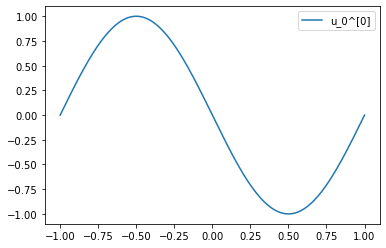

In [14]:
for i in range(M):
    plt.plot(x[:,0], u_0[i,:,0], label=f"u_0^[{i}]")

plt.legend()
plt.show()

In [29]:
psi_0 = np.zeros_like(x)

for i in range(M):
    psi_0 += p - u_0[i]

psi_0 /= M

N_psi = np.linalg.norm(psi_0)
psi_0 /= N_psi

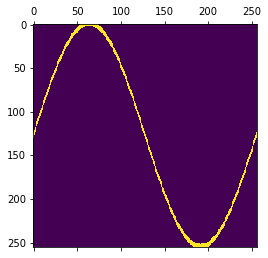

In [31]:
plt.matshow(np.rot90((np.abs(psi_0) < 1e-4)))
plt.show()

In [33]:
# psi_tmp = np.copy(psi_0)
# for i in range(N):
#     psi_tmp[i] /= np.linalg.norm(psi_0[i])

# plt.plot(x[:,0], np.sum(p * np.abs(psi_tmp) ** 2, axis=1))
# plt.show()

In [34]:
discrete_gradient = diags([-np.ones(N-1), np.zeros(N), np.ones(N-1)], offsets=[-1,0,1])

In [35]:
discrete_gradient = discrete_gradient.tolil()

In [36]:
# periodic boundary conditions
discrete_gradient[0,N-1] = -1
discrete_gradient[N-1,0] = 1

discrete_gradient /= 2 * h

In [37]:
discrete_gradient_vec = np.zeros(N)

# second order central differences (flipped)
discrete_gradient_vec[1] = -0.5
discrete_gradient_vec[-1] = 0.5

discrete_gradient_vec /= h

evals = np.fft.fft(discrete_gradient_vec)

In [38]:
T = 0.3
N_t = 5 # time points

In [39]:
# %matplotlib

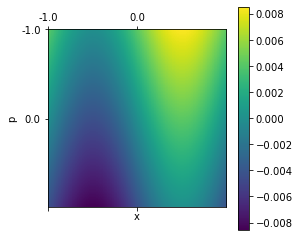

In [40]:
plt.matshow(np.rot90(psi_0))
# plt.title(f"t={t}")
plt.xlabel("x")
plt.xticks(np.arange(N, step=128), np.round(x[::128,0], decimals=2))
plt.ylabel("p")
plt.yticks(np.arange(N_p, step=128), np.round(p[0,::128], decimals=2))
plt.colorbar()
# plt.savefig(join(IMG_DIR, f"level_set_{t : 0.3f}.png"), dpi=100, facecolor="white")
plt.show()

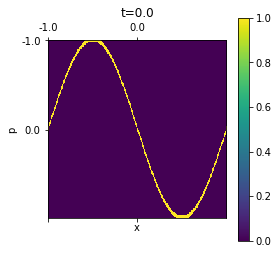

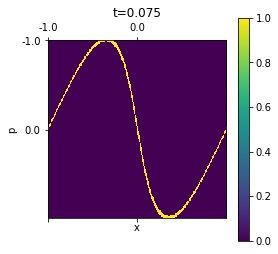

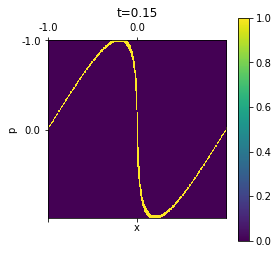

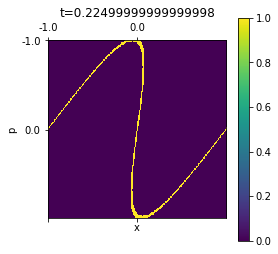

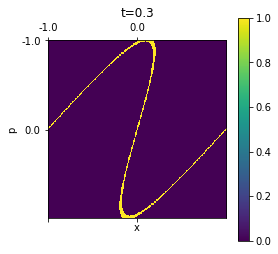

In [44]:
for t in np.linspace(0, T, N_t):
    psi = np.zeros_like(psi_0)
    for i,p_val in enumerate(np.linspace(L, R, N_p)):

        psi[:,i] = ifft(np.exp(-(p_val) * t * evals) * fft(psi_0[:,i])).real
        # psi[:,i] = expm_multiply(-p_val * discrete_gradient * t, psi_0[:,i])
    # plt.matshow(np.rot90(psi))
    plt.matshow(np.rot90((np.abs(psi) < 1e-4)))
    plt.title(f"t={t}")
    plt.xlabel("x")
    plt.xticks(np.arange(N, step=128), np.round(x[::128,0], decimals=2))
    plt.ylabel("p")
    plt.yticks(np.arange(N_p, step=128), np.round(p[0,::128], decimals=2))
    plt.colorbar()
    plt.savefig(join(IMG_DIR, f"level_set_{t : 0.2f}.png"), dpi=100, facecolor="white")
    plt.show()

    # psi_tmp = np.copy(psi)
    # for i in range(N):
    #     psi_tmp[i] /= np.linalg.norm(psi[i])

    # exp_g = np.sum(p * np.abs(psi_tmp) ** 2, axis=1)
    # plt.plot(x[:,0], exp_g)
    # plt.title(f"Expectation for g(p)=p at t={t : 0.2f}")
    # plt.xlabel("x")
    # plt.xticks(np.round(x[::128,0], decimals=2))
    # plt.show()